<a href="https://colab.research.google.com/github/phnkalda/Mesin-Learning/blob/main/Salinan_dari_uts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/deteksi_berita.csv.csv')
df.head()

,judul,link,status
0,Zulhas: Program Makan Bergizi Gratis Jangkau 6...,https://sultra.antaranews.com/berita/527646/zu...,Real
1,[HOAKS] Penyaluran MBG Diubah Jadi Uang Tunai ...,https://dinkominfo.purworejokab.go.id/hoaks-pe...,Fake
2,Satgas MBG Cianjur Hentikan Sementara Dapur SP...,https://www.antaranews.com/berita/4422315/satg...,Real
3,Pemerintah Kembali Memulai Pelaksanaan Program...,https://www.youtube.com/watch?v=Bbfp8gDdlXY,Real
4,Pemerintah Siapkan Rp335 Triliun untuk Program...,https://www.antaranews.com/berita/527646/pemer...,Real


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
print(df.info())
print(df['status'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   judul   50 non-null     object
 1   link    50 non-null     object
 2   status  50 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB
None
status
Real    32
Fake    18
Name: count, dtype: int64


In [ ]:
df = df[['judul', 'status']]

x = df['judul']
y = df['status']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorize = TfidfVectorizer()
X_tfidf = vectorize.fit_transform(x)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()
nb.fit(x_train, y_train)

y_pred_nb = nb.predict(x_test)

print("Akurasi Naive Bayes:", accuracy_score(y_test, y_pred_nb))

Akurasi Naive Bayes: 0.5


In [ ]:
from sklearn.svm import SVC
svm =SVC()
svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

        Fake       0.00      0.00      0.00         5
        Real       0.50      1.00      0.67         5

    accuracy                           0.50        10
   macro avg       0.25      0.50      0.33        10
weighted avg       0.25      0.50      0.33        10



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


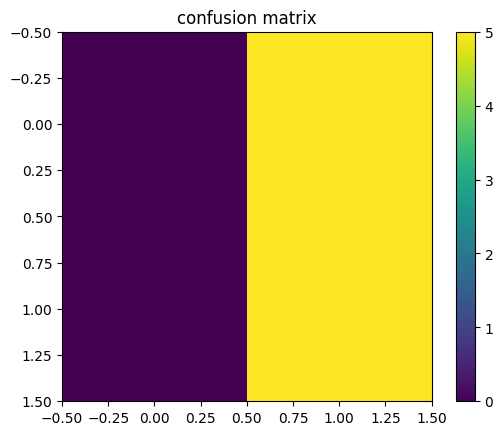

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_nb)

plt.imshow(cm)
plt.title("confusion matrix")
plt.colorbar()
plt.show()

In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

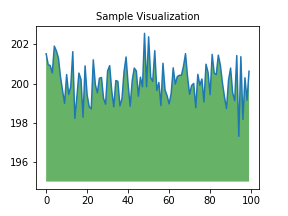

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)